In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in data, here the top scores for each protein/TRN pair (top RFI)
df = pd.read_csv("data/top_protein_trn_score_matrix.csv", index_col=0)

In [3]:
# Get top score per protein, sort, and include cutoff for top 10%
top_per_protein = df.T.max(axis=0)
sorted_vals = np.sort(top_per_protein.values)[::-1]

n = len(sorted_vals)
cutoff = int(0.10 * n)

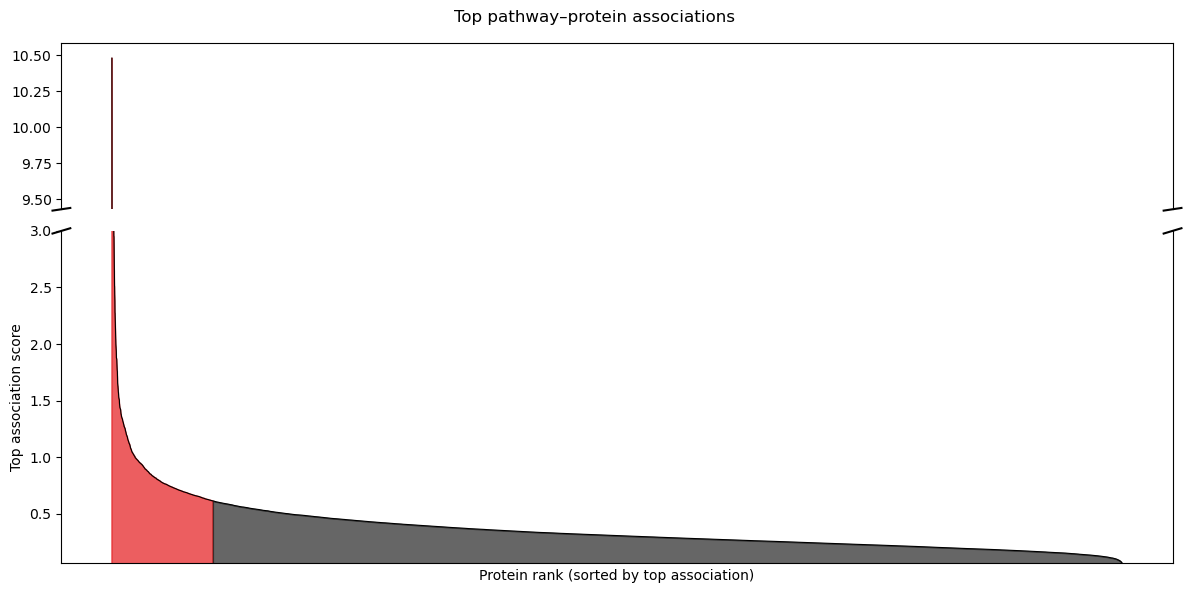

In [4]:
# Create a figure with two vertically stacked subplots (broken y-axis layout)

# Top panel (ax_top) will show the extreme high values
# Bottom panel (ax_bottom) will show the bulk of the distribution
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(12, 6),
    gridspec_kw={'height_ratios': [1, 2]}  # top is smaller than bottom
)

# Define where to "break" the y-axis
y_break = 3

# Set y-limits:
# Bottom shows full range up to break
ax_bottom.set_ylim(sorted_vals.min(), y_break)

# Top shows only the highest values (zoomed-in "sliver")
ax_top.set_ylim(sorted_vals.max() * 0.9, sorted_vals.max() * 1.01)

# Plot data on both panels

# Plot full line (same data on both panels)
ax_bottom.plot(sorted_vals, color="black", linewidth=0.8)
ax_top.plot(sorted_vals, color="black", linewidth=0.8)

# Highlight top-ranked region (left side, up to cutoff) in red
ax_bottom.fill_between(range(cutoff), sorted_vals[:cutoff], color="#e41a1c", alpha=0.7)
ax_top.fill_between(range(cutoff), sorted_vals[:cutoff], color="#e41a1c", alpha=0.7)

# Remaining values plotted in black
ax_bottom.fill_between(range(cutoff, n), sorted_vals[cutoff:], color="black", alpha=0.6)
ax_top.fill_between(range(cutoff, n), sorted_vals[cutoff:], color="black", alpha=0.6)

# Store the y-value at the cutoff (useful if you want to annotate threshold later)
red_shift_y = sorted_vals[cutoff]

# Clean up axes for broken-axis effect

# Remove the connecting spines between the two panels
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Hide x-axis labels on top panel
ax_top.tick_params(labeltop=False)

# Add diagonal "break" marks to indicate discontinuity ----
d = 0.008  # size of diagonal lines

# Top panel diagonals
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)           # left diagonal
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)     # right diagonal

# Bottom panel diagonals
kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # left diagonal
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # right diagonal

# Labels and title

ax_bottom.set_xlabel("Protein rank (sorted by top association)")
ax_bottom.set_ylabel("Top association score")
fig.suptitle("Top pathway–protein associations")

# Remove x-axis ticks/labels (clean look for ranked plot)
ax_top.set_xticks([])
ax_top.set_xticklabels([])
ax_bottom.set_xticks([])
ax_bottom.set_xticklabels([])

# Show figure
plt.tight_layout()
plt.show()